In [44]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/labelResultAll.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/1893.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/1711.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/4682.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/5064.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/3504.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/1269.jpg
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/3863.jpg
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/1773.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/623.jpg
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/559.txt
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/3750.jpg
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/2008.jpg
/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data/1812.txt
/ka

In [45]:
import os
import pandas as pd
from PIL import Image
from transformers import BertTokenizer
from torchvision import transforms
from torch.utils.data import Dataset
import torch

In [46]:
def load_texts(folder):
    files = sorted(
        [f for f in os.listdir(folder) if f.endswith('.txt')],
        key=lambda x: int(x.split('.')[0])
    )

    texts = []
    for f in files:
        with open(os.path.join(folder, f), 'r', encoding='latin-1', errors='ignore') as file:
            texts.append(file.read().strip())

    return texts, files

In [47]:
def load_labels(label_path):
    text_labels, image_labels = {}, {}

    with open(label_path, 'r') as f:
        next(f)  # skip header

        for line in f:
            idx, val = line.strip().split('\t')
            t, i = val.split(',')

            text_labels[int(idx)] = t.strip().lower()
            image_labels[int(idx)] = i.strip().lower()

    return text_labels, image_labels

In [48]:
print(os.listdir("/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single"))

['data', 'labelResultAll.txt']


In [49]:
text_dir = "/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/data"
label_file = "/kaggle/input/datasets/vincemarcs/mvsasingle/MVSA_Single/labelResultAll.txt"

all_texts, _ = load_texts(text_dir)
text_labels, image_labels = load_labels(label_file)

texts, image_paths, final_labels = [], [], []

for i, text in enumerate(all_texts):
    idx = i + 1
    img_path = os.path.join(text_dir, f"{idx}.jpg")

    if os.path.exists(img_path) and idx in text_labels and idx in image_labels:

        t_lbl = text_labels[idx]
        i_lbl = image_labels[idx]

        # 🔥 YOUR SMART LOGIC (KEPT)
        final_lbl = t_lbl if t_lbl == i_lbl else (
            t_lbl if i_lbl == 'neutral' else i_lbl
        )

        texts.append(text)
        image_paths.append(img_path)
        final_labels.append(final_lbl)

In [50]:
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}

labels = [label2id[l] for l in final_labels]

In [51]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_imgs, val_imgs, y_train, y_val = train_test_split(
    texts, image_paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [52]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [53]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [54]:
class MVSADataset(Dataset):
    def __init__(self, texts, images, labels, tokenizer, transform):
        self.texts = texts
        self.images = images
        self.labels = labels
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        # IMAGE
        image = Image.open(self.images[idx]).convert("RGB")
        image = self.transform(image)

        # TEXT
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=64,
            return_tensors="pt"
        )

        return {
            "image": image,
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

In [55]:
train_dataset = MVSADataset(train_texts, train_imgs, y_train, tokenizer, train_transform)
val_dataset   = MVSADataset(val_texts, val_imgs, y_val, tokenizer, val_transform)

In [56]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torchvision.models as models

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [59]:
from transformers import BertModel

class TextModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.fc = nn.Linear(768, 3)

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).pooler_output
        return self.fc(x)

In [60]:
class ImageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(512, 3)

    def forward(self, x):
        return self.resnet(x)

In [61]:
class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.text_model = BertModel.from_pretrained("bert-base-uncased")
        self.image_model = models.resnet18(pretrained=True)
        self.image_model.fc = nn.Identity()

        self.text_proj = nn.Linear(768, 256)
        self.image_proj = nn.Linear(512, 256)

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 3)
        )

    def forward(self, input_ids, attention_mask, image):
        t = self.text_model(input_ids=input_ids,
                            attention_mask=attention_mask).pooler_output
        t = self.text_proj(t)

        i = self.image_proj(self.image_model(image))

        x = torch.cat([t, i], dim=1)
        return self.fc(x)

In [62]:
def train_model(model, loader, optimizer, criterion, mode):
    model.train()
    total_loss, correct, total = 0, 0, 0

    loop = tqdm(loader, desc=f"Training {mode}", leave=False)

    for batch in loop:
        optimizer.zero_grad()

        labels = batch["label"].to(device)

        if mode == "text":
            outputs = model(batch["input_ids"].to(device),
                            batch["attention_mask"].to(device))

        elif mode == "image":
            outputs = model(batch["image"].to(device))

        else:
            outputs = model(batch["input_ids"].to(device),
                            batch["attention_mask"].to(device),
                            batch["image"].to(device))

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

        loop.set_postfix(loss=loss.item(), acc=correct/total)

    return total_loss/len(loader), correct/total

In [63]:
def evaluate(model, loader, mode):
    model.eval()
    all_preds, all_labels = [], []

    loop = tqdm(loader, desc=f"Evaluating {mode}", leave=False)

    with torch.no_grad():
        for batch in loop:

            labels = batch["label"].to(device)

            if mode == "text":
                outputs = model(batch["input_ids"].to(device),
                                batch["attention_mask"].to(device))

            elif mode == "image":
                outputs = model(batch["image"].to(device))

            else:
                outputs = model(batch["input_ids"].to(device),
                                batch["attention_mask"].to(device),
                                batch["image"].to(device))

            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    print(f"\n{mode.upper()} Accuracy: {acc:.4f}\n")

    print(classification_report(
        all_labels,
        all_preds,
        target_names=["negative","neutral","positive"]
    ))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{mode.upper()} Confusion Matrix")
    plt.show()

    return acc

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text Epoch 1 | Loss: 0.8929 | Acc: 0.6040


Text Epoch 2 | Loss: 0.8274 | Acc: 0.6284


Text Epoch 3 | Loss: 0.7278 | Acc: 0.6846


...

Text Epoch 7 | Loss: 0.1816 | Acc: 0.9363


Text Epoch 8 | Loss: 0.1266 | Acc: 0.9542


Text Epoch 9 | Loss: 0.1013 | Acc: 0.9620


Text Epoch 10 | Loss: 0.0703 | Acc: 0.9742



TEXT Accuracy: 0.6095

              precision    recall  f1-score   support

    negative       0.48      0.53      0.50       268
     neutral       0.39      0.16      0.23        93
    positive       0.69      0.72      0.71       561

    accuracy                           0.61       922
   macro avg       0.52      0.47      0.48       922
weighted avg       0.60      0.61      0.60       922



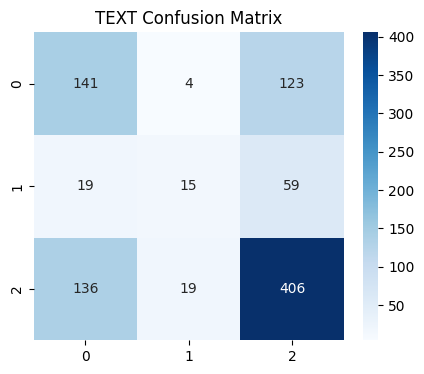

In [64]:
text_model = TextModel().to(device)

optimizer = optim.Adam(text_model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    loss, acc = train_model(text_model, train_loader, optimizer, criterion, "text")
    print(f"Text Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

text_acc = evaluate(text_model, val_loader, "text")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Image Epoch 1 | Loss: 0.9205 | Acc: 0.5647


Image Epoch 2 | Loss: 0.8030 | Acc: 0.6320


Image Epoch 3 | Loss: 0.7723 | Acc: 0.6553


Image Epoch 4 | Loss: 0.7360 | Acc: 0.6642


...

Image Epoch 7 | Loss: 0.6371 | Acc: 0.7206


Image Epoch 8 | Loss: 0.6172 | Acc: 0.7301


Image Epoch 9 | Loss: 0.5737 | Acc: 0.7526


Image Epoch 10 | Loss: 0.5583 | Acc: 0.7665



IMAGE Accuracy: 0.6421

              precision    recall  f1-score   support

    negative       0.64      0.16      0.25       268
     neutral       0.47      0.25      0.32        93
    positive       0.65      0.94      0.77       561

    accuracy                           0.64       922
   macro avg       0.59      0.45      0.45       922
weighted avg       0.63      0.64      0.57       922



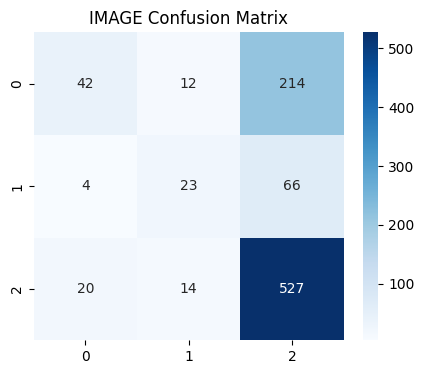

In [65]:
image_model = ImageModel().to(device)

optimizer = optim.Adam(image_model.parameters(), lr=1e-4)

for epoch in range(10):
    loss, acc = train_model(image_model, train_loader, optimizer, criterion, "image")
    print(f"Image Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

image_acc = evaluate(image_model, val_loader, "image")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/mod

Fusion Epoch 1 | Loss: 0.8664 | Acc: 0.6124


Fusion Epoch 2 | Loss: 0.8107 | Acc: 0.6320


Fusion Epoch 3 | Loss: 0.7772 | Acc: 0.6439


...

Fusion Epoch 7 | Loss: 0.6798 | Acc: 0.6973


Fusion Epoch 8 | Loss: 0.6601 | Acc: 0.7014


Fusion Epoch 9 | Loss: 0.6546 | Acc: 0.7155


Fusion Epoch 10 | Loss: 0.5997 | Acc: 0.7323



FUSION Accuracy: 0.6562

              precision    recall  f1-score   support

    negative       0.57      0.37      0.45       268
     neutral       0.39      0.32      0.35        93
    positive       0.71      0.85      0.77       561

    accuracy                           0.66       922
   macro avg       0.56      0.51      0.53       922
weighted avg       0.64      0.66      0.64       922



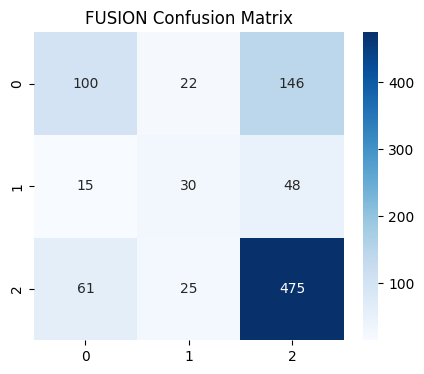

In [66]:
fusion_model = FusionModel().to(device)

optimizer = optim.Adam(fusion_model.parameters(), lr=1e-4)

for epoch in range(10):
    loss, acc = train_model(fusion_model, train_loader, optimizer, criterion, "fusion")
    print(f"Fusion Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

fusion_acc = evaluate(fusion_model, val_loader, "fusion")

In [67]:
def get_val_loss(model, loader, criterion, mode):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            labels = batch["label"].to(device)

            if mode == "text":
                outputs = model(batch["input_ids"].to(device),
                                batch["attention_mask"].to(device))

            elif mode == "image":
                outputs = model(batch["image"].to(device))

            else:  # fusion
                outputs = model(batch["input_ids"].to(device),
                                batch["attention_mask"].to(device),
                                batch["image"].to(device))

            loss = criterion(outputs, labels)
            total_loss += loss.item()

    return total_loss / len(loader)

In [71]:
def train_and_collect(model, train_loader, val_loader, optimizer, criterion, mode, epochs=5):
    train_losses, train_accs = [], []
    val_losses, val_accs = [],[]

    for epoch in range(epochs):
        # your existing function (unchanged)
        train_loss, train_acc = train_model(
            model, train_loader, optimizer, criterion, mode
        )

        # your existing evaluate (accuracy only)
        val_acc = evaluate(model, val_loader, mode)

        # separate loss calculation
        val_loss = get_val_loss(model, val_loader, criterion, mode)

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"{mode.upper()} Epoch {epoch+1} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_losses, train_accs, val_losses, val_accs

In [72]:
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, train_accs, val_accs, title="Model"):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, marker='o', label="Train Loss")
    plt.plot(epochs, val_losses, marker='o', label="Val Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accs, marker='o', label="Train Acc")
    plt.plot(epochs, val_accs, marker='o', label="Val Acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()


TEXT Accuracy: 0.6095

              precision    recall  f1-score   support

    negative       0.48      0.53      0.50       268
     neutral       0.39      0.16      0.23        93
    positive       0.69      0.72      0.71       561

    accuracy                           0.61       922
   macro avg       0.52      0.47      0.48       922
weighted avg       0.60      0.61      0.60       922



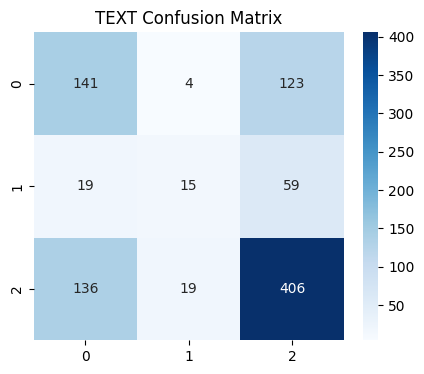

TEXT Epoch 1 | Train Loss: 0.0406, Train Acc: 0.9851 | Val Loss: 1.9450, Val Acc: 0.6095



TEXT Accuracy: 0.6095

              precision    recall  f1-score   support

    negative       0.48      0.53      0.50       268
     neutral       0.39      0.16      0.23        93
    positive       0.69      0.72      0.71       561

    accuracy                           0.61       922
   macro avg       0.52      0.47      0.48       922
weighted avg       0.60      0.61      0.60       922



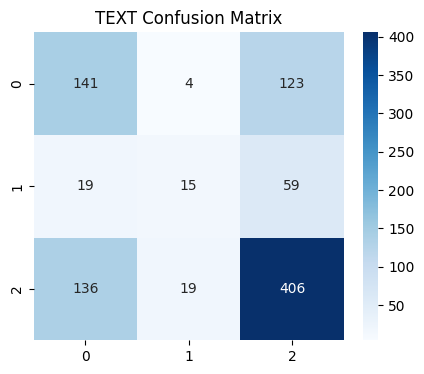

TEXT Epoch 2 | Train Loss: 0.0437, Train Acc: 0.9845 | Val Loss: 1.9450, Val Acc: 0.6095



TEXT Accuracy: 0.6095

              precision    recall  f1-score   support

    negative       0.48      0.53      0.50       268
     neutral       0.39      0.16      0.23        93
    positive       0.69      0.72      0.71       561

    accuracy                           0.61       922
   macro avg       0.52      0.47      0.48       922
weighted avg       0.60      0.61      0.60       922



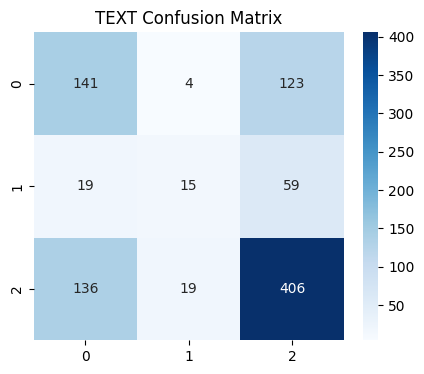

TEXT Epoch 3 | Train Loss: 0.0405, Train Acc: 0.9851 | Val Loss: 1.9450, Val Acc: 0.6095



TEXT Accuracy: 0.6095

              precision    recall  f1-score   support

    negative       0.48      0.53      0.50       268
     neutral       0.39      0.16      0.23        93
    positive       0.69      0.72      0.71       561

    accuracy                           0.61       922
   macro avg       0.52      0.47      0.48       922
weighted avg       0.60      0.61      0.60       922



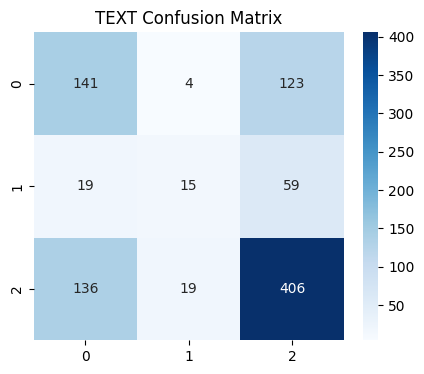

TEXT Epoch 4 | Train Loss: 0.0430, Train Acc: 0.9835 | Val Loss: 1.9450, Val Acc: 0.6095



TEXT Accuracy: 0.6095

              precision    recall  f1-score   support

    negative       0.48      0.53      0.50       268
     neutral       0.39      0.16      0.23        93
    positive       0.69      0.72      0.71       561

    accuracy                           0.61       922
   macro avg       0.52      0.47      0.48       922
weighted avg       0.60      0.61      0.60       922



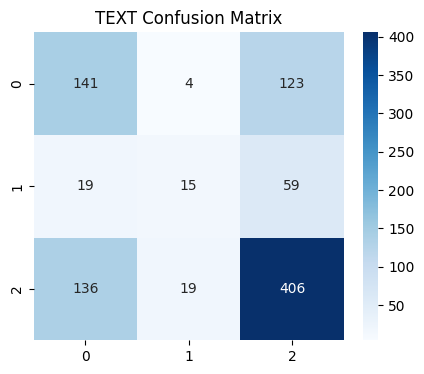

TEXT Epoch 5 | Train Loss: 0.0396, Train Acc: 0.9867 | Val Loss: 1.9450, Val Acc: 0.6095


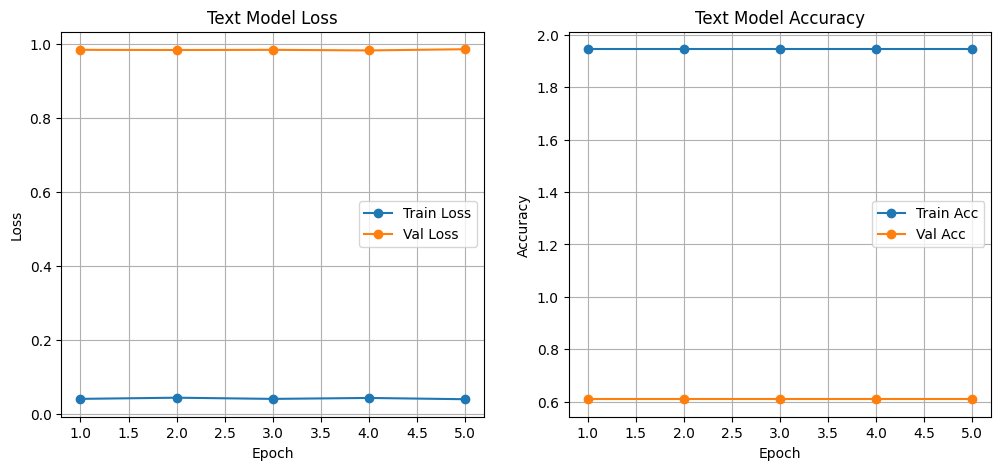

In [74]:
text_metrics = train_and_collect(
    text_model, train_loader, val_loader,
    optimizer, criterion, mode="text", epochs=5
)

plot_metrics(*text_metrics, title="Text Model")


IMAGE Accuracy: 0.6377

              precision    recall  f1-score   support

    negative       0.52      0.37      0.43       268
     neutral       0.40      0.25      0.31        93
    positive       0.69      0.83      0.75       561

    accuracy                           0.64       922
   macro avg       0.54      0.48      0.50       922
weighted avg       0.61      0.64      0.61       922



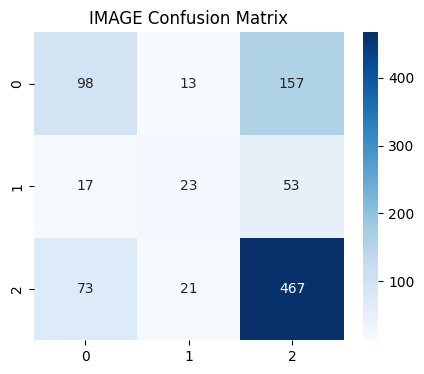

IMAGE Epoch 1 | Train Loss: 0.4949, Train Acc: 0.7993 | Val Loss: 0.9323, Val Acc: 0.6377



IMAGE Accuracy: 0.6421

              precision    recall  f1-score   support

    negative       0.53      0.35      0.42       268
     neutral       0.46      0.28      0.35        93
    positive       0.68      0.84      0.76       561

    accuracy                           0.64       922
   macro avg       0.56      0.49      0.51       922
weighted avg       0.62      0.64      0.62       922



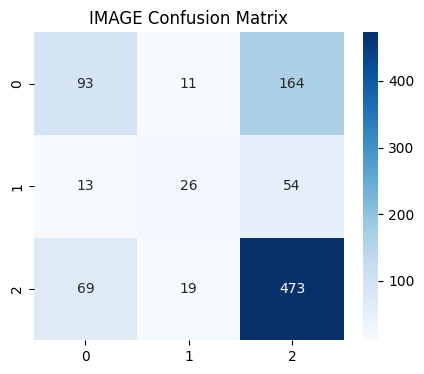

IMAGE Epoch 2 | Train Loss: 0.4889, Train Acc: 0.7936 | Val Loss: 0.9358, Val Acc: 0.6421



IMAGE Accuracy: 0.6334

              precision    recall  f1-score   support

    negative       0.53      0.31      0.39       268
     neutral       0.44      0.26      0.33        93
    positive       0.67      0.85      0.75       561

    accuracy                           0.63       922
   macro avg       0.55      0.47      0.49       922
weighted avg       0.61      0.63      0.60       922



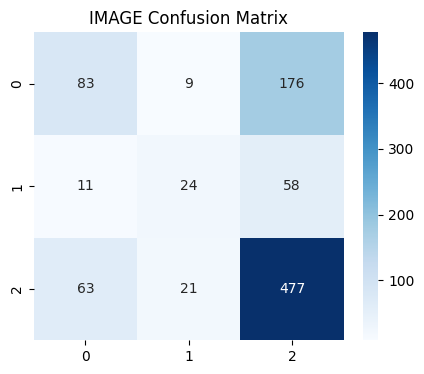

IMAGE Epoch 3 | Train Loss: 0.5097, Train Acc: 0.7906 | Val Loss: 0.9633, Val Acc: 0.6334



IMAGE Accuracy: 0.6410

              precision    recall  f1-score   support

    negative       0.52      0.32      0.40       268
     neutral       0.48      0.28      0.35        93
    positive       0.68      0.85      0.76       561

    accuracy                           0.64       922
   macro avg       0.56      0.48      0.50       922
weighted avg       0.61      0.64      0.61       922



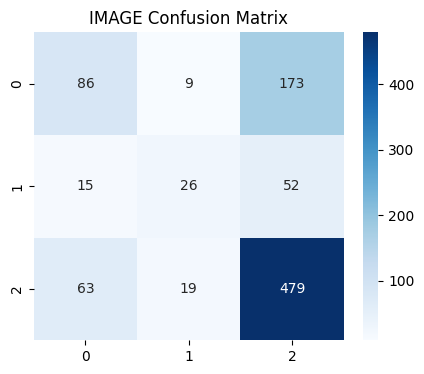

IMAGE Epoch 4 | Train Loss: 0.4946, Train Acc: 0.8017 | Val Loss: 0.9451, Val Acc: 0.6410



IMAGE Accuracy: 0.6443

              precision    recall  f1-score   support

    negative       0.53      0.38      0.44       268
     neutral       0.46      0.28      0.35        93
    positive       0.69      0.83      0.76       561

    accuracy                           0.64       922
   macro avg       0.56      0.50      0.52       922
weighted avg       0.62      0.64      0.62       922



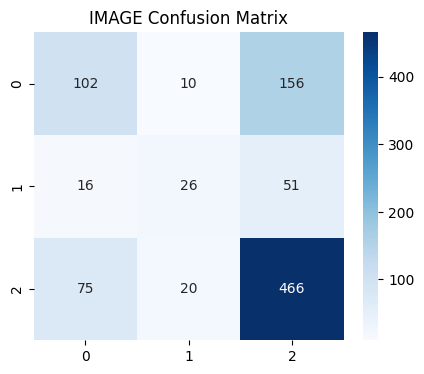

IMAGE Epoch 5 | Train Loss: 0.5062, Train Acc: 0.7890 | Val Loss: 0.9173, Val Acc: 0.6443


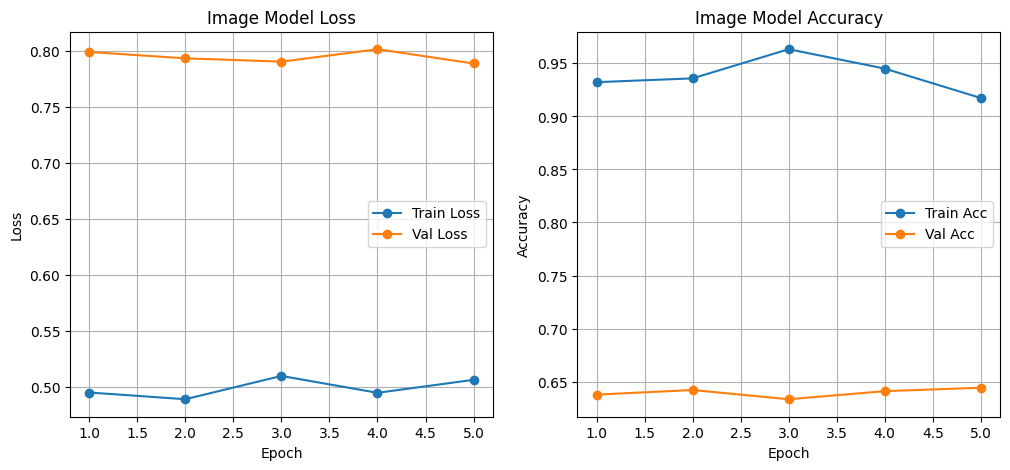

In [75]:
image_metrics = train_and_collect(
    image_model, train_loader, val_loader,
    optimizer, criterion, mode="image", epochs=5
)

plot_metrics(*image_metrics, title="Image Model")


FUSION Accuracy: 0.6540

              precision    recall  f1-score   support

    negative       0.54      0.45      0.49       268
     neutral       0.41      0.26      0.32        93
    positive       0.71      0.82      0.76       561

    accuracy                           0.65       922
   macro avg       0.56      0.51      0.52       922
weighted avg       0.63      0.65      0.64       922



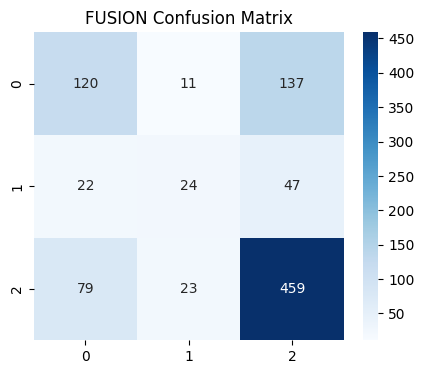

FUSION Epoch 1 | Train Loss: 0.5961, Train Acc: 0.7442 | Val Loss: 0.9770, Val Acc: 0.6540



FUSION Accuracy: 0.6302

              precision    recall  f1-score   support

    negative       0.54      0.38      0.45       268
     neutral       0.35      0.40      0.37        93
    positive       0.71      0.79      0.74       561

    accuracy                           0.63       922
   macro avg       0.53      0.52      0.52       922
weighted avg       0.62      0.63      0.62       922



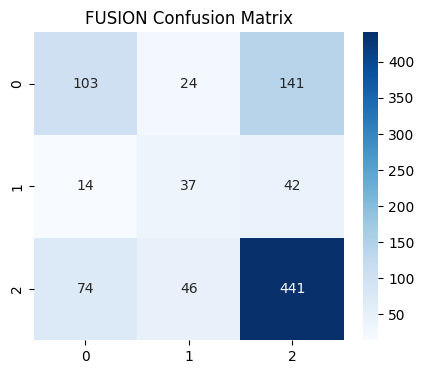

FUSION Epoch 2 | Train Loss: 0.5738, Train Acc: 0.7575 | Val Loss: 0.9849, Val Acc: 0.6302



FUSION Accuracy: 0.6269

              precision    recall  f1-score   support

    negative       0.50      0.45      0.47       268
     neutral       0.34      0.28      0.31        93
    positive       0.72      0.77      0.74       561

    accuracy                           0.63       922
   macro avg       0.52      0.50      0.51       922
weighted avg       0.61      0.63      0.62       922



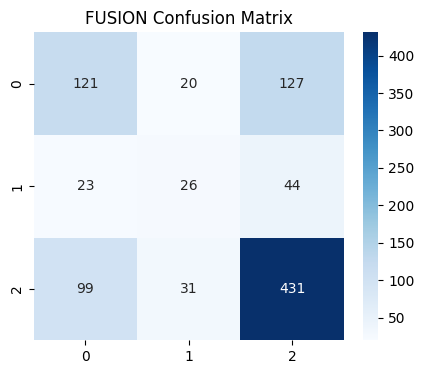

FUSION Epoch 3 | Train Loss: 0.5437, Train Acc: 0.7714 | Val Loss: 0.9796, Val Acc: 0.6269



FUSION Accuracy: 0.6594

              precision    recall  f1-score   support

    negative       0.59      0.38      0.46       268
     neutral       0.45      0.37      0.40        93
    positive       0.70      0.84      0.77       561

    accuracy                           0.66       922
   macro avg       0.58      0.53      0.54       922
weighted avg       0.64      0.66      0.64       922



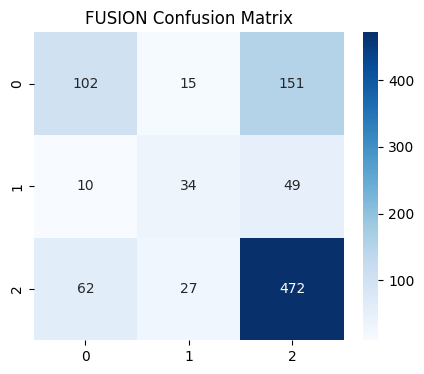

FUSION Epoch 4 | Train Loss: 0.5239, Train Acc: 0.7803 | Val Loss: 1.1108, Val Acc: 0.6594



FUSION Accuracy: 0.6128

              precision    recall  f1-score   support

    negative       0.52      0.41      0.46       268
     neutral       0.34      0.38      0.36        93
    positive       0.69      0.75      0.72       561

    accuracy                           0.61       922
   macro avg       0.52      0.51      0.51       922
weighted avg       0.61      0.61      0.61       922



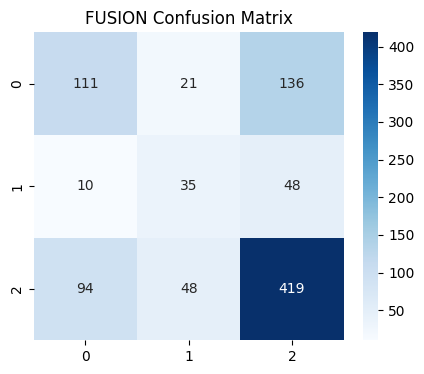

FUSION Epoch 5 | Train Loss: 0.5107, Train Acc: 0.7882 | Val Loss: 1.0347, Val Acc: 0.6128


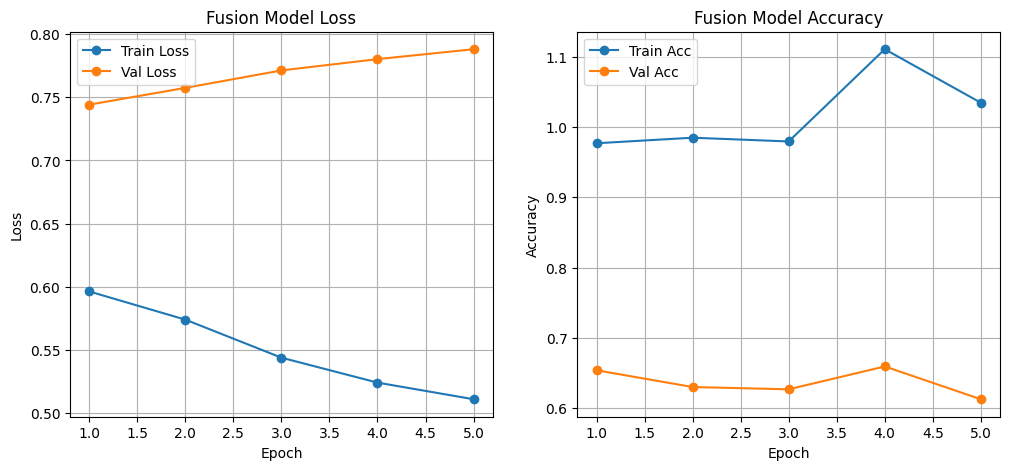

In [76]:
fusion_metrics = train_and_collect(
    fusion_model, train_loader, val_loader,
    optimizer, criterion, mode="fusion", epochs=5
)

plot_metrics(*fusion_metrics, title="Fusion Model")

In [78]:
results = pd.DataFrame({
    "Model": ["Text", "Image", "Fusion"],
    "Accuracy": [text_acc, image_acc, fusion_acc]
})

print(results)

    Model  Accuracy
0    Text  0.609544
1   Image  0.642082
2  Fusion  0.656182


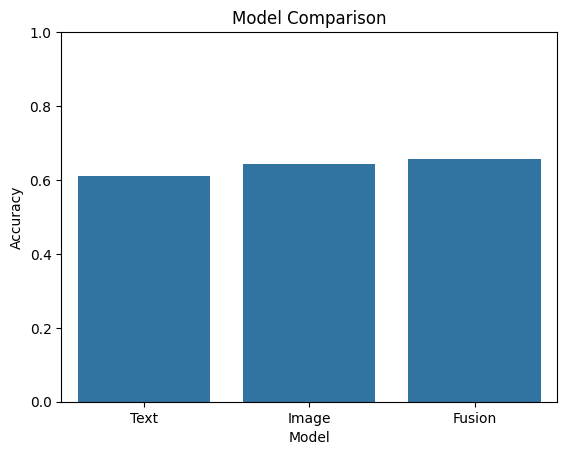

In [79]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()

In [80]:
import numpy as np
import torch
from PIL import Image

def predict(model, mode, image_path, caption):
    model.eval()

    # 🖼️ IMAGE
    image = Image.open(image_path).convert("RGB")
    image = val_transform(image).unsqueeze(0).to(device)

    # 📝 TEXT
    encoding = tokenizer(
        caption,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=64
    )

    ids = encoding["input_ids"].to(device)
    mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        if mode == "text":
            out = model(ids, mask)

        elif mode == "image":
            out = model(image)

        else:  # fusion
            out = model(ids, mask, image)

        probs = torch.softmax(out, dim=1)[0].cpu().numpy()
        pred = id2label[np.argmax(probs)]

    return pred, probs

Technique used in Paper

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
print("LR Accuracy:", accuracy_score(y_val, y_pred_lr))

LR Accuracy: 0.5379609544468547


In [86]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)
print("XGB Accuracy:", accuracy_score(y_val, y_pred_xgb))

XGB Accuracy: 0.6095444685466378


In [89]:
lr_acc=accuracy_score(y_val, y_pred_lr)
xgb_acc=accuracy_score(y_val, y_pred_xgb)

In [87]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy',
        n_jobs=-1
    )

    plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

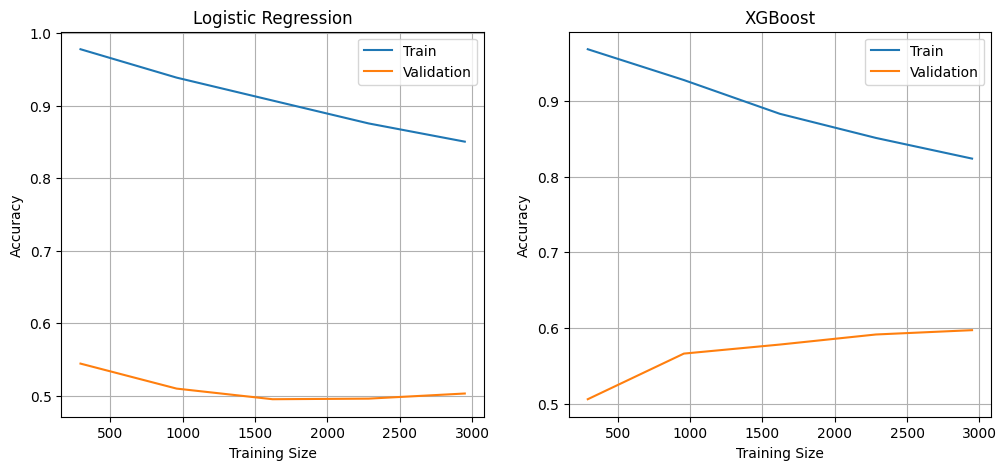

In [88]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_curve(lr, X_train, y_train, "Logistic Regression")

plt.subplot(1,2,2)
plot_curve(xgb, X_train, y_train, "XGBoost")

plt.show()

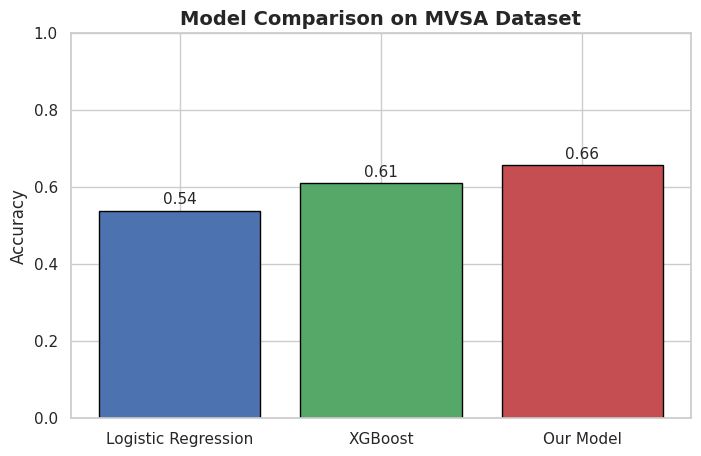

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: makes it more aesthetic
sns.set(style="whitegrid")

models = ["Logistic Regression", "XGBoost", "Our Model"]
accuracies = [lr_acc, xgb_acc, fusion_acc]

colors = ["#4C72B0", "#55A868", "#C44E52"]  # nice pastel tones

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies, color=colors, edgecolor="black")

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height:.2f}",
             ha='center', va='bottom', fontsize=11)

plt.title("Model Comparison on MVSA Dataset", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()